# 02 · Metrics & Efficiency Analysis — U-Net

Publication figures and tables for the 5-phase study, built **only** from the consolidated files in
`<pipeline>/summary/` (written by `unet/build_final_report.py`; same schema as YOLO26) plus the raw latency samples in
`phase5_test/efficiency/*.json`. No GPU is needed.

| Figure | Question it answers |
|---|---|
| 1 | Does accuracy (DSC, JSI) hold from cross-validation to the test set, and what does HPO add? |
| 2 | Is the HPO gain on the test set significant (paired, per image)? |
| 3 | How does accuracy scale with model size and compute? |
| 4 | Latency vs. FPS for FP32 and FP16 (network forward vs. full `predict()`). |
| 5 | How stable is the latency (median and P95)? |
| 6 | Memory footprint (VRAM, RAM). |
| 7 | Accuracy–latency trade-off for deployment. |
| A | Accuracy (DSC, JSI, Boundary IoU) vs. latency, FPS and parameters — standard in the three repositories. |
| B | Training time per phase and inference time (median, P95) with the real-time criterion — standard. |
| C | Boundary metrics (Boundary IoU, NSD, HD95) with 95 % CI — standard. |

Figures are saved as PDF (vector, for LaTeX) and PNG under `<pipeline>/figures/`; LaTeX tables under `<pipeline>/tables/`.
Colours follow a CVD-validated categorical palette; every chart also has a legend and a table view.

In [14]:
# ---- Configuration ----------------------------------------------------------
PIPELINE_NAME = "pipeline_final_v1"   # sub-directory of logs/ (or set $PIPELINE_DIR)
DEPLOY_VARIANT = "optimized"          # variant shown in the efficiency figures


import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Locate the repository and the pipeline outputs ------------------------
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()


def find_pipeline_dir(name: str) -> Path | None:
    """$PIPELINE_DIR, else the Docker mount, else <repo>/logs/<name>; None if none exists yet."""
    candidates = [os.environ.get("PIPELINE_DIR"), f"/workspace/logs/{name}", REPO_ROOT / "logs" / name]
    for c in candidates:
        if c and Path(c).is_dir():
            return Path(c)
    print(f"[info] pipeline outputs not found; tried {candidates}. Set PIPELINE_DIR.")
    return None


#: Where the YOLO26 dataset (images + labels, the source of truth) may live on the host.
YOLO_DATASET_CANDIDATES = [REPO_ROOT / "datasets" / "isic2018_task1_official",
                           REPO_ROOT.parent / "sandbox_yolo26" / "datasets" / "isic2018_task1_official",
                           # earlier export (results produced before the official-release rebuild)
                           REPO_ROOT / "datasets" / "isic_2018_task1_yolo26",
                           REPO_ROOT.parent / "sandbox_yolo26" / "datasets" / "isic_2018_task1_yolo26"]


def local_path(p) -> Path:
    """Map /workspace/... paths recorded inside Docker to this machine when run on the host."""
    p = Path(p)
    if p.exists():
        return p
    s = str(p)
    for prefix in ("/workspace/yolo26_dataset/", "/workspace/datasets/isic2018_task1_official/",
                   "/workspace/datasets/isic_2018_task1_yolo26/"):
        if s.startswith(prefix):
            for root in YOLO_DATASET_CANDIDATES:
                if (root / s[len(prefix):]).exists():
                    return root / s[len(prefix):]
    if s.startswith("/workspace/") and (REPO_ROOT / p.relative_to("/workspace")).exists():
        return REPO_ROOT / p.relative_to("/workspace")
    return p


PHASE5_MISSING = "⚠️ Phase 5 results not yet generated. Training is likely still in progress. Skipping cell execution."
PHASE5_READY = False   # set by the data-loading cell; every later cell is skipped while it is False
PIPELINE_DIR = find_pipeline_dir(PIPELINE_NAME) or REPO_ROOT / "logs" / PIPELINE_NAME
FIG_DIR = PIPELINE_DIR / "figures"

# ---- Figure style (publication, light) -------------------------------------
INK, INK_2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#ffffff"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "axes.labelcolor": INK_2, "axes.edgecolor": INK_2, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK,
    "legend.frameon": False, "legend.fontsize": 8, "lines.linewidth": 2, "lines.markersize": 7,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})


def save(fig, name: str) -> None:
    """Save a figure as vector PDF (for LaTeX) and 300-dpi PNG under <pipeline>/figures/."""
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{ext}", bbox_inches="tight", dpi=300)
    print(f"saved {FIG_DIR / name}.pdf|png")


print("pipeline :", PIPELINE_DIR)
print("figures  :", FIG_DIR)


MODELS = ["unet"]
SHORT = {"unet": "U-Net"}
# Categorical colours: validated light-mode slots (all-pairs CVD ΔE ≥ 9). Colour follows the entity.
SERIES = {"cv": "#2a78d6", "baseline": "#eb6834", "optimized": "#1baf7a"}
SERIES_LABEL = {"cv": "Phase 2 · 5-fold CV (held-out folds)",
                "baseline": "Phase 5 · Test — Baseline", "optimized": "Phase 5 · Test — Optimized"}
PREC = {"fp32": "#2a78d6", "fp16": "#4a3aa7"}
MARKER = {"baseline": "s", "optimized": "o", "fp32": "o", "fp16": "^"}
TABLE_DIR = PIPELINE_DIR / "tables"

pipeline : /home/antoniovinicius/projects/sandbox_unet/logs/pipeline_final_v1
figures  : /home/antoniovinicius/projects/sandbox_unet/logs/pipeline_final_v1/figures


In [15]:
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter


def log_axis(ax, axis: str = "x") -> None:
    """Log scale with plain-number ticks (1-2-5, 1-3 or decades, by the span of the data); call after plotting."""
    (ax.set_xscale if axis == "x" else ax.set_yscale)("log")
    a = ax.xaxis if axis == "x" else ax.yaxis
    lo, hi = ax.get_xlim() if axis == "x" else ax.get_ylim()
    span = np.log10(hi / lo) if lo > 0 and hi > lo else 1.0
    a.set_major_locator(LogLocator(base=10, subs=(1.0, 2.0, 5.0) if span <= 1.6 else (1.0, 3.0) if span <= 2.6 else (1.0,)))
    a.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}" if v >= 1 else f"{v:g}"))
    a.set_minor_formatter(NullFormatter())


SUMMARY = PIPELINE_DIR / "summary"


def read_csv(name: str) -> pd.DataFrame:
    p = SUMMARY / f"{name}.csv"
    if not p.exists():
        print(f"[missing] {p} — run build_final_report.py")
        return pd.DataFrame()
    return pd.read_csv(p)


acc, eff, gain, cv_pix, cv_inst = (read_csv(n) for n in
                                   ("test_accuracy", "efficiency", "hpo_gain", "phase2_cv_pixel", "phase2_cv_baseline"))
report = json.loads((SUMMARY / "final_results.json").read_text()) if (SUMMARY / "final_results.json").exists() else {}

present = set(acc["model"]) if len(acc) else set()
MODELS = [m for m in MODELS if m in present] or MODELS
X = np.arange(len(MODELS))
acc32 = acc[acc.precision == "fp32"] if len(acc) else acc

print(f"models: {MODELS}")
for w in report.get("warnings", []):
    print("WARNING:", w)

PHASE5_READY = not acc.empty and not eff.empty
if not PHASE5_READY:
    print(PHASE5_MISSING)

models: ['unet']


## Figure 1 — DSC and JSI across phases

Per model: Phase 2 cross-validation (mean ± sample SD over the 5 held-out folds; Baseline protocol), and the test set
for the Baseline and the Optimized models (per-image mean with seeded bootstrap 95 % CI). A dot plot is used because
the values are close together; bars would have to start at zero and hide the differences.

saved /home/antoniovinicius/projects/sandbox_unet/logs/pipeline_final_v1/figures/fig1_dsc_jsi_across_phases.pdf|png


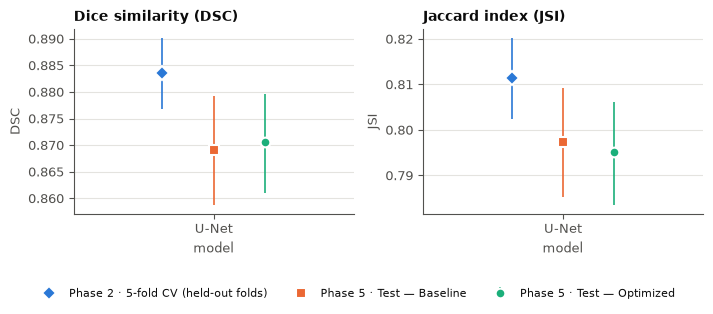

,model,cv_dsc_mean,cv_dsc_std,cv_jsi_mean,cv_jsi_std,test_baseline_dsc_mean,test_baseline_dsc_ci95_low,test_baseline_dsc_ci95_high,test_baseline_jsi_mean,test_optimized_dsc_mean,test_optimized_dsc_ci95_low,test_optimized_dsc_ci95_high,test_optimized_jsi_mean
0,unet,0.8835,0.0068,0.8114,0.0089,0.8692,0.8587,0.8792,0.7974,0.8706,0.8609,0.8796,0.7951


In [16]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    def series_stats(key: str, metric: str):
        """(mean, 2×N error) — CV: ± sample SD over folds; test: bootstrap 95 % CI."""
        if key == "cv":
            d = cv_pix.set_index("model").reindex(MODELS)
            return d[f"{metric}_mean"].to_numpy(), np.vstack([d[f"{metric}_std"].to_numpy()] * 2)
        d = acc32[acc32.variant == key].set_index("model").reindex(MODELS)
        m = d[f"{metric}_mean"].to_numpy()
        return m, np.vstack([m - d[f"{metric}_ci95_low"].to_numpy(), d[f"{metric}_ci95_high"].to_numpy() - m])


    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.9))
    offsets = {"cv": -0.22, "baseline": 0.0, "optimized": 0.22}
    for ax, metric, title in zip(axes, ("dsc", "jsi"), ("Dice similarity (DSC)", "Jaccard index (JSI)")):
        for key in ("cv", "baseline", "optimized"):
            if key == "cv" and cv_pix.empty:
                continue
            mean, err = series_stats(key, metric)
            ax.errorbar(X + offsets[key], mean, yerr=err, fmt=MARKER.get(key, "D"),
                        color=SERIES[key], ecolor=SERIES[key], elinewidth=1.2, capsize=0,
                        markeredgecolor=SURFACE, markeredgewidth=1.5, markersize=7, label=SERIES_LABEL[key])
        ax.set_xticks(X, [SHORT[m] for m in MODELS])
        ax.set_xlim(-0.6, len(MODELS) - 0.4)   # keep the three series grouped around each model
        ax.set_xlabel("model")
        ax.set_title(title)
        ax.set_ylabel(metric.upper())
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.08))
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    save(fig, "fig1_dsc_jsi_across_phases")
    plt.show()

    table1 = pd.DataFrame({"model": MODELS})
    if not cv_pix.empty:
        table1 = table1.merge(cv_pix[["model", "dsc_mean", "dsc_std", "jsi_mean", "jsi_std"]]
                              .rename(columns=lambda c: c if c == "model" else f"cv_{c}"), on="model", how="left")
    for v in ("baseline", "optimized"):
        d = acc32[acc32.variant == v][["model", "dsc_mean", "dsc_ci95_low", "dsc_ci95_high", "jsi_mean"]]
        table1 = table1.merge(d.rename(columns=lambda c: c if c == "model" else f"test_{v}_{c}"), on="model", how="left")
    display(table1.round(4))

## Figure 2 — HPO gain on the test set (paired)

Optimized − Baseline per image on the same test images: mean difference with paired bootstrap 95 % CI.
The label is the two-sided Wilcoxon signed-rank *p*-value. An interval that crosses zero means no reliable gain.

saved /home/antoniovinicius/projects/sandbox_unet/logs/pipeline_final_v1/figures/fig2_hpo_gain.pdf|png


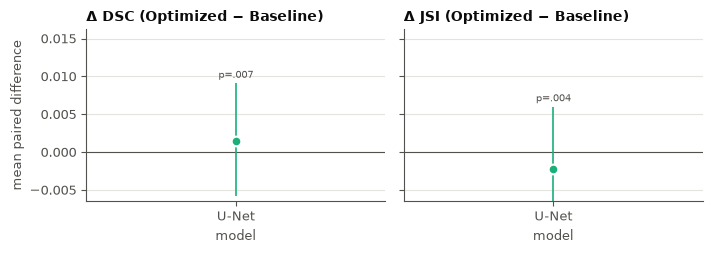

,n_images,dsc_baseline,dsc_optimized,delta_dsc,delta_dsc_ci95_low,delta_dsc_ci95_high,wilcoxon_p_dsc,n_improved_dsc,n_worse_dsc,delta_jsi,wilcoxon_p_jsi,delta_map5095_m
model,,,,,,,,,,,,
unet,1000,0.8692,0.8706,0.0014,-0.0057,0.0091,0.0074,444,556,-0.0023,0.0045,NaN


In [17]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    def fmt_p(p: float) -> str:
        """APA-style p-value label."""
        if not np.isfinite(p):
            return "p = n/a"
        return "p<.001" if p < 0.001 else f"p={p:.3f}".replace("0.", ".")


    if gain.empty:
        print("hpo_gain.csv missing — run Phase 5")
    else:
        g = gain.set_index("model").reindex(MODELS)
        fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.6), sharey=True)
        for ax, k, title in zip(axes, ("dsc", "jsi"), ("Δ DSC (Optimized − Baseline)", "Δ JSI (Optimized − Baseline)")):
            d = g[f"delta_{k}"].to_numpy()
            err = np.vstack([d - g[f"delta_{k}_ci95_low"].to_numpy(), g[f"delta_{k}_ci95_high"].to_numpy() - d])
            ax.axhline(0, color=INK_2, linewidth=0.8)
            ax.errorbar(X, d, yerr=err, fmt="o", color=SERIES["optimized"], elinewidth=1.2, capsize=0,
                        markeredgecolor=SURFACE, markeredgewidth=1.5, markersize=7)
            for xi, di, hi, p in zip(X, d, g[f"delta_{k}_ci95_high"], g[f"wilcoxon_p_{k}"]):
                ax.annotate(fmt_p(p), (xi, hi), xytext=(0, 4), textcoords="offset points",
                            ha="center", fontsize=7, color=INK_2)
            lo, hi_ = ax.get_ylim()
            ax.set_ylim(min(lo, 0), hi_ + 0.18 * (hi_ - min(lo, 0)))  # headroom for the p labels
            ax.set_xlim(-0.6, len(MODELS) - 0.4)
            ax.set_xticks(X, [SHORT[m] for m in MODELS])
            ax.set_xlabel("model")
            ax.set_title(title)
        axes[0].set_ylabel("mean paired difference")
        fig.tight_layout()
        save(fig, "fig2_hpo_gain")
        plt.show()
        display(gain.set_index("model").reindex(MODELS)[
            ["n_images", "dsc_baseline", "dsc_optimized", "delta_dsc", "delta_dsc_ci95_low", "delta_dsc_ci95_high",
             "wilcoxon_p_dsc", "n_improved_dsc", "n_worse_dsc", "delta_jsi", "wilcoxon_p_jsi", "delta_map5095_m"]].round(4))

## Figure 3 — Accuracy vs. model size and compute

Test-set accuracy against the FP32 weight size (fused parameters × 4 bytes) and GFLOPs at the U-Net's native
256×256 input (the resolution-matched GFLOPs at 640×640, `gflops_640`, are in `phase5_test/efficiency/*.json`).
Metrics that do not exist for the U-Net (Ultralytics mask mAP, NaN) are omitted. The x-axes are logarithmic.

saved /home/antoniovinicius/projects/sandbox_unet/logs/pipeline_final_v1/figures/fig3_accuracy_vs_size.pdf|png


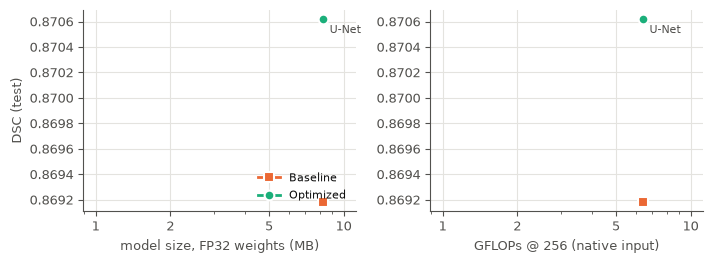

,baseline · dsc_mean,optimized · dsc_mean,size_mb_fp32_theoretical,size_mb_disk,gflops,params_fused
model,,,,,,
unet,0.8692,0.8706,8.2348,8.3017,6.4005,2158705


In [18]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    cost = (eff[(eff.variant == DEPLOY_VARIANT) & (eff.precision == "fp32")]
            .set_index("model")[["size_mb_fp32_theoretical", "size_mb_disk", "gflops", "params_fused"]])
    rows3 = [(mt, lab) for mt, lab in (("map5095_m", "mask mAP@50-95 (test)"), ("dsc_mean", "DSC (test)"))
             if acc32[mt].notna().any()]
    fig, axes = plt.subplots(len(rows3), 2, figsize=(7.2, 2.7 * len(rows3)), sharex="col", squeeze=False)
    for row, (metric, ylab) in enumerate(rows3):
        for col, (cx, xlab) in enumerate((("size_mb_fp32_theoretical", "model size, FP32 weights (MB)"), ("gflops", "GFLOPs @ 256 (native input)"))):
            ax = axes[row, col]
            for v in ("baseline", "optimized"):
                d = acc32[acc32.variant == v].set_index("model").reindex(MODELS).join(cost)
                ax.plot(d[cx], d[metric], color=SERIES[v], marker=MARKER[v], markeredgecolor=SURFACE,
                        markeredgewidth=1.5, label=SERIES_LABEL[v].split("— ")[1])
                if v == "optimized":
                    for m, xv, yv in zip(MODELS, d[cx], d[metric]):
                        ax.annotate(SHORT[m], (xv, yv), xytext=(5, -10), textcoords="offset points", fontsize=8, color=INK_2)
            log_axis(ax, "x")
            ax.grid(True, axis="both")
            if row == len(rows3) - 1:
                ax.set_xlabel(xlab)
            if col == 0:
                ax.set_ylabel(ylab)
    axes[0, 0].legend(loc="lower right")
    fig.tight_layout()
    save(fig, "fig3_accuracy_vs_size")
    plt.show()
    t3 = acc32.pivot(index="model", columns="variant", values=[mt for mt, _ in rows3]).reindex(MODELS)
    t3.columns = [f"{v} · {k}" for k, v in t3.columns]
    display(t3.join(cost).round(4))

## Figure 4 — Latency vs. FPS (batch = 1)

Each point is one model at one precision. Filled markers: network forward pass (timed with `torch.cuda.Event`);
hollow markers: full `predict()` (pre-processing + inference + mask post-processing). FPS = 1000 / mean latency,
so points lie near the grey reference curve; what matters is how far along it each model sits and the
forward → end-to-end gap. Baseline and Optimized share the architecture, so only the deployed variant is shown.

saved /home/antoniovinicius/projects/sandbox_unet/logs/pipeline_final_v1/figures/fig4_latency_vs_fps.pdf|png


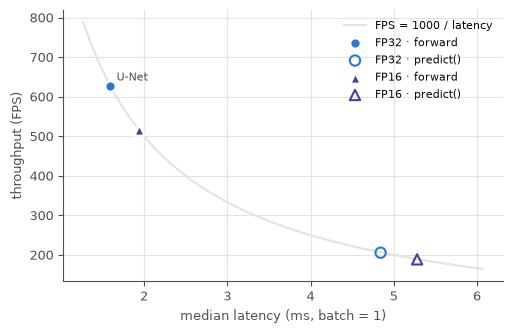

fwd_median_ms  fwd_p95_ms  fwd_p99_ms  fwd_fps  \
model precision                                                   
unet  fp32                1.59        1.68        1.87   626.82   
      fp16                1.93        2.00        2.27   515.11   

                 e2e_median_ms  e2e_p95_ms  e2e_fps  e2e_dataset_median_ms  \
model precision                                                              
unet  fp32                4.84        5.04   205.62                   5.05   
      fp16                5.28        5.52   188.77                   5.26   

                 e2e_dataset_p95_ms  contended  
model precision                                 
unet  fp32                     5.57       True  
      fp16                     5.60       True

In [19]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    e = eff[eff.variant == DEPLOY_VARIANT]
    fig, ax = plt.subplots(figsize=(5.2, 3.4))
    lat = np.linspace(max(0.5, e[["fwd_median_ms", "e2e_median_ms"]].min().min() * 0.8),
                      e[["fwd_median_ms", "e2e_median_ms"]].max().max() * 1.15, 200)
    ax.plot(lat, 1000 / lat, color=GRID, linewidth=1.5, zorder=0, label="FPS = 1000 / latency")
    for prec in ("fp32", "fp16"):
        d = e[e.precision == prec].set_index("model").reindex(MODELS)
        ax.scatter(d.fwd_median_ms, d.fwd_fps, color=PREC[prec], marker=MARKER[prec], s=55,
                   edgecolor=SURFACE, linewidth=1.5, label=f"{prec.upper()} · forward", zorder=3)
        ax.scatter(d.e2e_median_ms, d.e2e_fps, facecolor="none", edgecolor=PREC[prec], marker=MARKER[prec],
                   s=55, linewidth=1.5, label=f"{prec.upper()} · predict()", zorder=3)
        if prec == "fp32":
            for m, xv, yv in zip(MODELS, d.fwd_median_ms, d.fwd_fps):
                ax.annotate(SHORT[m], (xv, yv), xytext=(5, 4), textcoords="offset points", fontsize=8, color=INK_2)
    ax.set_xlabel("median latency (ms, batch = 1)")
    ax.set_ylabel("throughput (FPS)")
    ax.grid(True, axis="both")
    ax.legend(ncol=1, loc="upper right")
    fig.tight_layout()
    save(fig, "fig4_latency_vs_fps")
    plt.show()
    display(e.set_index(["model", "precision"])[
        [c for c in ("fwd_median_ms", "fwd_p95_ms", "fwd_p99_ms", "fwd_fps", "e2e_median_ms", "e2e_p95_ms", "e2e_fps",
                     "e2e_dataset_median_ms", "e2e_dataset_p95_ms", "contended") if c in e]
    ].reindex(MODELS, level=0).round(2))

## Figure 5 — Latency distribution (median and P95)

Box = interquartile range, centre line = median, whiskers = P5–P95 of the timed forward passes
(warm-up excluded). A short upper whisker means a stable, predictable latency.

saved /home/antoniovinicius/projects/sandbox_unet/logs/pipeline_final_v1/figures/fig5_latency_distribution.pdf|png


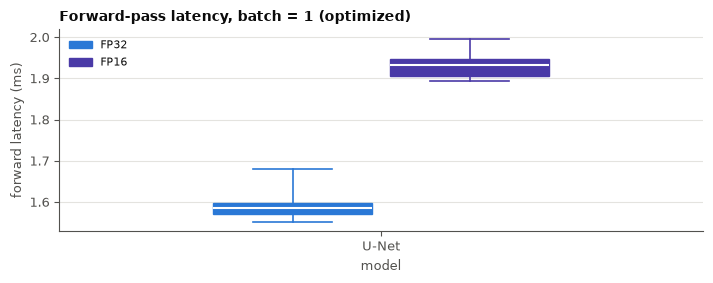

,median,P95,P99,P95 − median
unet/fp32,1.586,1.681,1.868,0.095
unet/fp16,1.933,1.998,2.269,0.064


In [20]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    raw = {}
    for m in MODELS:
        for prec in ("fp32", "fp16"):
            p = PIPELINE_DIR / "phase5_test" / "efficiency" / f"{DEPLOY_VARIANT}_{m}_{prec}.json"
            if p.exists():
                raw[(m, prec)] = json.loads(p.read_text())["forward"]["raw_ms"]

    fig, ax = plt.subplots(figsize=(7.2, 2.9))
    width = 0.34
    for i, prec in enumerate(("fp32", "fp16")):
        data = [raw.get((m, prec), [np.nan]) for m in MODELS]
        pos = X + (i - 0.5) * (width + 0.04)
        bp = ax.boxplot(data, positions=pos, widths=width, whis=(5, 95), showfliers=False, patch_artist=True,
                        medianprops=dict(color=SURFACE, linewidth=1.5),
                        boxprops=dict(facecolor=PREC[prec], edgecolor=PREC[prec]),
                        whiskerprops=dict(color=PREC[prec], linewidth=1.2), capprops=dict(color=PREC[prec], linewidth=1.2))
        bp["boxes"][0].set_label(prec.upper())
    ax.set_xticks(X, [SHORT[m] for m in MODELS])
    ax.set_xlabel("model")
    ax.set_ylabel("forward latency (ms)")
    ax.set_title(f"Forward-pass latency, batch = 1 ({DEPLOY_VARIANT})")
    ax.legend(loc="upper left")
    fig.tight_layout()
    save(fig, "fig5_latency_distribution")
    plt.show()
    display(pd.DataFrame({f"{m}/{p}": {"median": np.median(v), "P95": np.percentile(v, 95), "P99": np.percentile(v, 99),
                               "P95 − median": np.percentile(v, 95) - np.median(v)} for (m, p), v in raw.items()}).T.round(3))

## Figure 6 — Memory footprint

Peak GPU memory of batch-1 inference, measured two ways, and the peak host RAM of the benchmark process:
**allocator** = steady-state peak allocated by PyTorch (forward pass / full prediction pipeline; cuDNN autotuning
workspaces of the warm-up and the CUDA context excluded) — the model's own footprint; **process** = device memory
held by the benchmark process as reported by the driver (`nvidia-smi`), CUDA context, kernels and allocator cache
included — what a deployment GPU must actually provide.

saved /home/antoniovinicius/projects/sandbox_unet/logs/pipeline_final_v1/figures/fig6_memory.pdf|png


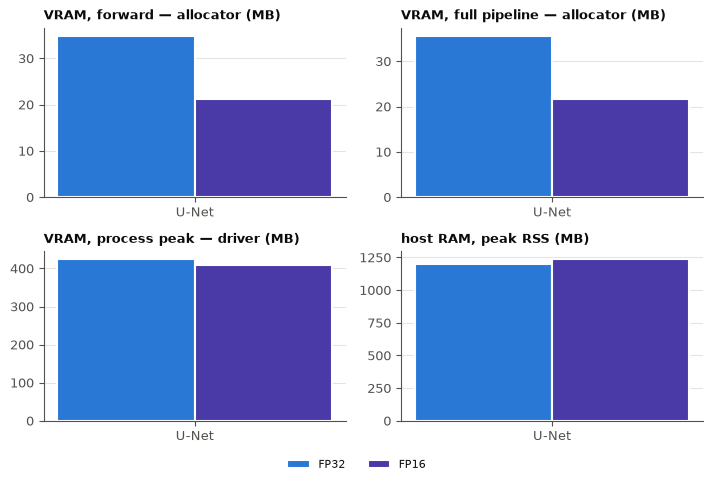

vram_weights_mb  vram_peak_allocated_mb  \
model precision                                            
unet  fp32                   8.2                    34.9   
      fp16                   4.1                    21.3   

                 vram_peak_allocated_e2e_mb  vram_cuda_context_mb  \
model precision                                                     
unet  fp32                             35.7                 370.0   
      fp16                             21.6                 370.0   

                 vram_process_peak_mb  ram_peak_rss_mb  size_mb_disk  \
model precision                                                        
unet  fp32                      424.0           1196.6           8.3   
      fp16                      408.0           1236.0           8.3   

                 size_mb_fp32_theoretical  size_mb_fp16_theoretical  \
model precision                                                       
unet  fp32                            8.2                       4.1   
      fp16                            8.2                       4.1   

                 params_fused  gflops  
model precision                        
unet  fp32            2158705     6.4  
      fp16            2158705     6.4

In [21]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    fig, axes = plt.subplots(2, 2, figsize=(7.2, 4.8))
    panels = (("vram_peak_allocated_mb", "VRAM, forward — allocator (MB)"),
              ("vram_peak_allocated_e2e_mb", "VRAM, full pipeline — allocator (MB)"),
              ("vram_process_peak_mb", "VRAM, process peak — driver (MB)"),
              ("ram_peak_rss_mb", "host RAM, peak RSS (MB)"))
    w = 0.38
    for ax, (col, title) in zip(axes.flat, panels):
        for i, prec in enumerate(("fp32", "fp16")):
            d = e[e.precision == prec].set_index("model").reindex(MODELS)
            v = d[col] if col in d else pd.Series(np.nan, index=d.index)
            ax.bar(X + (i - 0.5) * w, v, width=w, color=PREC[prec], edgecolor=SURFACE, linewidth=1.5, label=prec.upper())
        ax.set_xticks(X, [SHORT[m] for m in MODELS])
        ax.set_title(title, fontsize=9)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.01))
    fig.tight_layout(rect=(0, 0.04, 1, 1))
    save(fig, "fig6_memory")
    plt.show()
    display(e.set_index(["model", "precision"])[
        [c for c in ("vram_weights_mb", "vram_peak_allocated_mb", "vram_peak_allocated_e2e_mb", "vram_cuda_context_mb",
                     "vram_process_peak_mb", "ram_peak_rss_mb", "size_mb_disk", "size_mb_fp32_theoretical",
                     "size_mb_fp16_theoretical", "params_fused", "gflops") if c in e]
    ].reindex(MODELS, level=0).round(1))

## Figure 7 — Accuracy–latency trade-off

Test DSC of the deployed variant against its end-to-end median latency, in FP32 and FP16
(FP16 accuracy is measured, not assumed). Models up and to the left dominate.

saved /home/antoniovinicius/projects/sandbox_unet/logs/pipeline_final_v1/figures/fig7_accuracy_latency_tradeoff.pdf|png


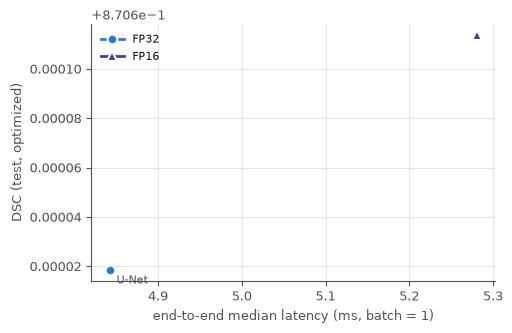

In [22]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    fig, ax = plt.subplots(figsize=(5.2, 3.4))
    for prec in ("fp32", "fp16"):
        a = acc[(acc.variant == DEPLOY_VARIANT) & (acc.precision == prec)].set_index("model").reindex(MODELS)
        l = e[e.precision == prec].set_index("model").reindex(MODELS)
        ax.plot(l.e2e_median_ms, a.dsc_mean, color=PREC[prec], marker=MARKER[prec], markeredgecolor=SURFACE,
                markeredgewidth=1.5, label=prec.upper())
        if prec == "fp32":
            for m, xv, yv in zip(MODELS, l.e2e_median_ms, a.dsc_mean):
                ax.annotate(SHORT[m], (xv, yv), xytext=(5, -10), textcoords="offset points", fontsize=8, color=INK_2)
    ax.set_xlabel("end-to-end median latency (ms, batch = 1)")
    ax.set_ylabel(f"DSC (test, {DEPLOY_VARIANT})")
    ax.grid(True, axis="both")
    ax.legend()
    fig.tight_layout()
    save(fig, "fig7_accuracy_latency_tradeoff")
    plt.show()

<!-- standard-committee-figures -->
## Standard figure A — Accuracy vs. efficiency (deployed variant, batch = 1)

Test-set accuracy — overlap (DSC, JSI) and contour adherence (Boundary IoU) — against the three deployment costs the
committee asked for: median forward latency, throughput (FPS) and parameter count. Each point is one model at one
precision (FP32 circles, FP16 triangles) with its seeded bootstrap 95 % CI; x-axes are logarithmic. Identical cell
in the YOLO26, U-Net and SAM 3 notebooks; the root notebook `04_cross_architecture_results.ipynb` draws the same plot
across architectures.

saved /home/antoniovinicius/projects/sandbox_unet/logs/pipeline_final_v1/figures/figA_accuracy_vs_efficiency.pdf|png


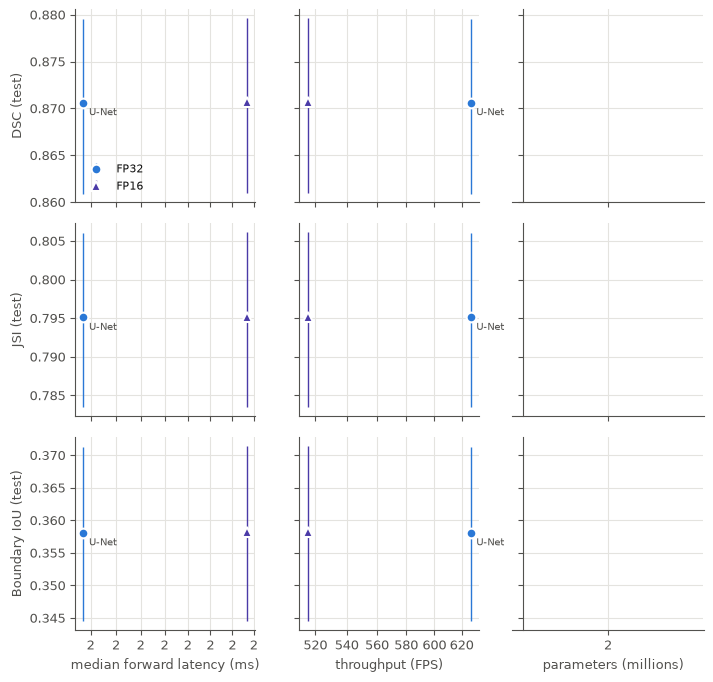

dsc_mean  dsc_ci95_low  dsc_ci95_high  jsi_mean  \
model precision                                                    
unet  fp32         0.8706        0.8609         0.8796    0.7951   
      fp16         0.8707        0.8610         0.8796    0.7952   

                 jsi_ci95_low  jsi_ci95_high  biou_mean  biou_ci95_low  \
model precision                                                          
unet  fp32             0.7834         0.8060     0.3581         0.3445   
      fp16             0.7836         0.8061     0.3582         0.3446   

                 biou_ci95_high  fwd_median_ms   fwd_fps  params_M  
model precision                                                     
unet  fp32               0.3713         1.5862  626.8173    2.1587  
      fp16               0.3714         1.9333  515.1064    2.1587

In [23]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    d_acc = acc[acc.variant == DEPLOY_VARIANT]
    d_eff = eff[eff.variant == DEPLOY_VARIANT]
    both = d_acc.merge(d_eff, on=["variant", "model", "precision"], suffixes=("", "_eff")).copy()   # de-fragment
    both["params_M"] = both["params_fused"] / 1e6
    y_rows = [("dsc", "DSC (test)"), ("jsi", "JSI (test)")]
    if "biou_mean" in both and both["biou_mean"].notna().any():
        y_rows.append(("biou", "Boundary IoU (test)"))
    x_cols = [("fwd_median_ms", "median forward latency (ms)"), ("fwd_fps", "throughput (FPS)"),
              ("params_M", "parameters (millions)")]
    fig, axes = plt.subplots(len(y_rows), len(x_cols), figsize=(7.2, 2.3 * len(y_rows)), squeeze=False,
                             sharex="col", sharey="row")
    for r, (yk, ylab) in enumerate(y_rows):
        for c, (xc, xlab) in enumerate(x_cols):
            ax = axes[r, c]
            for prec in ("fp32", "fp16"):
                d = both[both.precision == prec].set_index("model").reindex(MODELS)
                y = d[f"{yk}_mean"].to_numpy()
                yerr = np.vstack([y - d[f"{yk}_ci95_low"].to_numpy(), d[f"{yk}_ci95_high"].to_numpy() - y])
                ax.errorbar(d[xc], y, yerr=yerr, fmt=MARKER[prec], color=PREC[prec], elinewidth=1, capsize=0,
                            markersize=7, markeredgecolor=SURFACE, markeredgewidth=1.5, label=prec.upper(), zorder=3)
                if prec == "fp32":
                    for m, xv, yv in zip(MODELS, d[xc], y):
                        ax.annotate(SHORT[m], (xv, yv), xytext=(4, -9), textcoords="offset points", fontsize=7, color=INK_2)
            log_axis(ax, "x")
            ax.grid(True, axis="both")
            if r == len(y_rows) - 1:
                ax.set_xlabel(xlab)
            if c == 0:
                ax.set_ylabel(ylab)
    axes[0, 0].legend(loc="lower left")
    fig.tight_layout()
    save(fig, "figA_accuracy_vs_efficiency")
    plt.show()
    display(both.set_index(["model", "precision"])[
        [f"{k}_{s}" for k, _ in y_rows for s in ("mean", "ci95_low", "ci95_high")] + [c for c, _ in x_cols]
    ].reindex(MODELS, level=0).round(4))

## Standard figure B — Training and inference time

Left: wall-clock training time per phase (from every run's `results.csv`, validation included; `summary/training_cost.csv`).
Right: batch-1 inference time of the deployed variant — network forward pass vs. the full prediction pipeline
(image in host memory → binary mask at dataset resolution in host memory) — in FP32 and FP16: bar = median,
whisker = P95. The table below checks the **real-time criterion**: P95 end-to-end latency within the frame budget
of `REALTIME_FPS` (over the 100 distinct test images of the `end_to_end_dataset` scope when available).

saved /home/antoniovinicius/projects/sandbox_unet/logs/pipeline_final_v1/figures/figB_training_inference_time.pdf|png


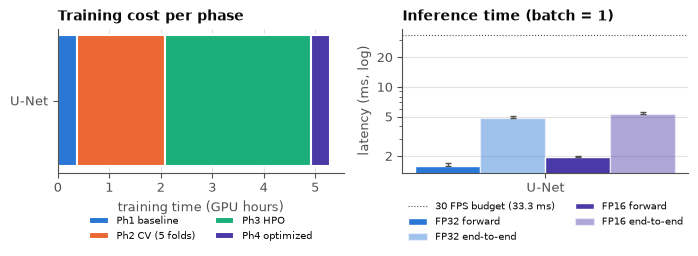

phase,phase1_baseline,phase2_cv_baseline,phase3_hpo,phase4_optimized
model,,,,
unet,0.38,1.7,2.83,0.38


fwd_median_ms  fwd_p95_ms  fwd_fps  e2e_median_ms  \
model precision                                                      
unet  fp32                1.59        1.68   626.82           4.84   
      fp16                1.93        2.00   515.11           5.28   

                 e2e_p95_ms  e2e_dataset_median_ms  e2e_dataset_p95_ms  \
model precision                                                          
unet  fp32             5.04                   5.05                5.57   
      fp16             5.52                   5.26                5.60   

                 e2e_fps  real-time (30 FPS, e2e_dataset_p95_ms)  
model precision                                                   
unet  fp32        205.62                                    True  
      fp16        188.77                                    True

In [24]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    REALTIME_FPS = 30   # frame-rate target of the real-time criterion (budget = 1000 / REALTIME_FPS ms)
    cost = read_csv("training_cost")
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8))
    if len(cost):
        phases = ["phase1_baseline", "phase2_cv_baseline", "phase3_hpo", "phase4_optimized"]
        labels = {"phase1_baseline": "Ph1 baseline", "phase2_cv_baseline": "Ph2 CV (5 folds)",
                  "phase3_hpo": "Ph3 HPO", "phase4_optimized": "Ph4 optimized"}
        colors = ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"]
        left = np.zeros(len(MODELS))
        for ph, col in zip(phases, colors):
            v = cost[cost.phase == ph].set_index("model").reindex(MODELS)["train_hours"].fillna(0).to_numpy()
            axes[0].barh(X, v, left=left, color=col, edgecolor=SURFACE, linewidth=1.5, label=labels[ph])
            left += v
        axes[0].set_yticks(X, [SHORT[m] for m in MODELS])
        axes[0].set_xlabel("training time (GPU hours)")
        axes[0].set_title("Training cost per phase")
        axes[0].grid(True, axis="x"); axes[0].grid(False, axis="y")
        axes[0].legend(fontsize=7, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.24))
    w = 0.2
    for i, (prec, scope) in enumerate([(p, s) for p in ("fp32", "fp16") for s in ("fwd", "e2e")]):
        d = eff[(eff.variant == DEPLOY_VARIANT) & (eff.precision == prec)].set_index("model").reindex(MODELS)
        med, p95 = d[f"{scope}_median_ms"].to_numpy(), d[f"{scope}_p95_ms"].to_numpy()
        xs = X + (i - 1.5) * w
        axes[1].bar(xs, med, width=w, color=PREC[prec], alpha=1.0 if scope == "fwd" else 0.45, edgecolor=SURFACE,
                    linewidth=1, label=f"{prec.upper()} {'forward' if scope == 'fwd' else 'end-to-end'}")
        axes[1].errorbar(xs, med, yerr=np.vstack([np.zeros_like(med), p95 - med]), fmt="none", ecolor=INK_2,
                         elinewidth=1, capsize=2)
    axes[1].axhline(1000 / REALTIME_FPS, color=INK_2, linewidth=0.8, linestyle=":",
                    label=f"{REALTIME_FPS} FPS budget ({1000 / REALTIME_FPS:.1f} ms)")
    axes[1].set_xticks(X, [SHORT[m] for m in MODELS])
    log_axis(axes[1], "y")
    axes[1].set_ylabel("latency (ms, log)")
    axes[1].set_title("Inference time (batch = 1)")
    axes[1].legend(fontsize=7, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.14))
    fig.tight_layout()
    save(fig, "figB_training_inference_time")
    plt.show()
    if len(cost):
        display(cost.pivot(index="model", columns="phase", values="train_hours").reindex(MODELS).round(2))
    rt = eff[eff.variant == DEPLOY_VARIANT].set_index(["model", "precision"]).reindex(MODELS, level=0)
    p95_col = "e2e_dataset_p95_ms" if "e2e_dataset_p95_ms" in rt and rt["e2e_dataset_p95_ms"].notna().all() else "e2e_p95_ms"
    realtime = rt[[c for c in ("fwd_median_ms", "fwd_p95_ms", "fwd_fps", "e2e_median_ms", "e2e_p95_ms",
                               "e2e_dataset_median_ms", "e2e_dataset_p95_ms", "e2e_fps") if c in rt]].copy()
    realtime[f"real-time ({REALTIME_FPS} FPS, {p95_col})"] = rt[p95_col] <= 1000 / REALTIME_FPS
    display(realtime.round(2))

## Standard figure C — Boundary metrics on the test set (Metrics Reloaded)

Boundary IoU (band = 2 % of the image diagonal), Normalised Surface Distance (tolerance = 1 % of the diagonal) and
HD95 (95th-percentile symmetric Hausdorff distance in pixels at dataset resolution; lower is better; a missed lesion
scores the image diagonal), per-image mean with seeded bootstrap 95 % CI, Baseline vs. Optimized (FP32). Overlap
scores (DSC, JSI) are dominated by the lesion interior; these scores measure contour adherence. The paired
Optimized − Baseline differences (bootstrap CI, Wilcoxon *p*) are in `summary/hpo_gain.csv`.

saved /home/antoniovinicius/projects/sandbox_unet/logs/pipeline_final_v1/figures/figC_boundary_metrics.pdf|png


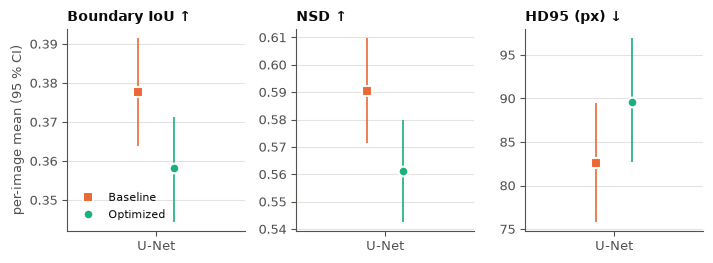

biou_mean  biou_std  biou_median  biou_ci95_low  \
model variant                                                      
unet  baseline      0.3776    0.2210       0.3688         0.3638   
      optimized     0.3581    0.2212       0.3337         0.3445   

                 biou_ci95_high  nsd_mean  nsd_std  nsd_median  nsd_ci95_low  \
model variant                                                                  
unet  baseline           0.3914    0.5905   0.3093      0.6164        0.5716   
      optimized          0.3713    0.5614   0.3064      0.5609        0.5427   

                 nsd_ci95_high  hd95_mean  hd95_std  hd95_median  \
model variant                                                      
unet  baseline          0.6096    82.6102  110.3094      31.1087   
      optimized         0.5799    89.5788  114.8108      39.5347   

                 hd95_ci95_low  hd95_ci95_high  
model variant                                   
unet  baseline         75.8549         89.5079  
      optimized        82.6953         96.8813

In [25]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    keys_c = [(k, t) for k, t in (("biou", "Boundary IoU ↑"), ("nsd", "NSD ↑"), ("hd95", "HD95 (px) ↓")) if f"{k}_mean" in acc32 and acc32[f"{k}_mean"].notna().any()]
    if not keys_c:
        print("Boundary metrics not in test_accuracy.csv — re-run Phase 5a (evaluate_test_set.py, EVAL_VERSION >= 3).")
    else:
        fig, axes = plt.subplots(1, len(keys_c), figsize=(7.2, 2.7), squeeze=False)
        for ax, (k, title) in zip(axes[0], keys_c):
            for off, v in ((-0.12, "baseline"), (0.12, "optimized")):
                d = acc32[acc32.variant == v].set_index("model").reindex(MODELS)
                m_ = d[f"{k}_mean"].to_numpy()
                err = np.vstack([m_ - d[f"{k}_ci95_low"].to_numpy(), d[f"{k}_ci95_high"].to_numpy() - m_])
                ax.errorbar(X + off, m_, yerr=err, fmt=MARKER[v], color=SERIES[v], elinewidth=1.2, capsize=0,
                            markeredgecolor=SURFACE, markeredgewidth=1.5, markersize=7, label=v.capitalize())
            ax.set_xticks(X, [SHORT[m] for m in MODELS])
            ax.set_xlim(-0.6, len(MODELS) - 0.4)
            ax.set_title(title)
        axes[0, 0].set_ylabel("per-image mean (95 % CI)")
        axes[0, 0].legend(loc="lower left")
        fig.tight_layout()
        save(fig, "figC_boundary_metrics")
        plt.show()
        display(acc32.set_index(["model", "variant"])[[c for c in acc32.columns if c.startswith(("biou_", "nsd_", "hd95_"))]]
                .reindex(MODELS, level=0).round(4))

## LaTeX tables
`booktabs` tables for the thesis, written to `<pipeline>/tables/`.

In [26]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    def to_latex(df: pd.DataFrame, name: str, caption: str) -> None:
        try:
            tex = df.to_latex(float_format="%.4f", caption=caption, label=f"tab:{name}", escape=True)
        except ImportError as err:  # pandas' LaTeX writer needs jinja2 (bundled with jupyterlab)
            print(f"[skip] {name}: {err}")
            return
        TABLE_DIR.mkdir(parents=True, exist_ok=True)
        (TABLE_DIR / f"{name}.tex").write_text(tex)
        print(f"saved {TABLE_DIR / name}.tex")


    if len(acc32):
        t = acc32.pivot(index="model", columns="variant",
                        values=[k for k in ("dsc_mean", "jsi_mean", "jsi_thr_mean", "biou_mean", "nsd_mean", "hd95_mean", "map5095_m") if k in acc32]).reindex(MODELS)
        t.columns = [f"{v} {k.replace('_mean', '').upper()}" for k, v in t.columns]
        t = t.dropna(axis=1, how="all")   # Ultralytics-only metrics are NaN for the U-Net
        to_latex(t, "test_accuracy", "Test-set accuracy of the Baseline and Optimized U-Net (FP32).")
    if len(e):
        t = e.set_index(["model", "precision"])[
            [c for c in ("params_fused", "gflops", "input_px", "size_mb_disk", "fwd_median_ms", "fwd_p95_ms", "fwd_fps",
                         "e2e_median_ms", "e2e_p95_ms", "e2e_dataset_p95_ms", "vram_peak_allocated_mb",
                         "vram_process_peak_mb") if c in e]
        ].reindex(MODELS, level=0)
        to_latex(t, "efficiency", "Batch-1 efficiency of the deployed U-Net (FP32 vs. FP16).")

[skip] test_accuracy: `Import Jinja2` failed. DataFrame.style requires jinja2. Use pip or conda to install the Jinja2 package.
[skip] efficiency: `Import Jinja2` failed. DataFrame.style requires jinja2. Use pip or conda to install the Jinja2 package.


## Reading notes

* **Contended runs.** `contended = True` means another process used the GPU during the benchmark;
  re-run Phase 5b on an idle GPU before quoting those latencies.
* **Model size.** `best.pt` holds the FP32 state dict, so `size_mb_disk` ≈ the FP32 size; the theoretical
  FP32/FP16 sizes are fused parameters × 4 / × 2 bytes.
* **VRAM.** `vram_peak_allocated_*` are PyTorch-allocator figures at steady state (the CUDA context, a few
  hundred MB, excluded); `vram_process_peak_mb` is the driver-level footprint of the benchmark process
  (context and allocator cache included) — quote it for "fits on device X" claims.
* **Latency scopes.** `fwd_*` = network only (CUDA events); `e2e_*` = full pipeline on one test image
  repeated; `e2e_dataset_*` = full pipeline once on each of 100 distinct test images (input-dependent
  spread). The per-image `infer_ms` column of `phase5_test/per_image/*.csv` is a by-product of Phase 5a,
  not a benchmark — never quote it.
* **CV vs. test.** CV uses the Baseline protocol on held-out folds of train+val; only Phase 5 touches the test set.